In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [3]:
df = pd.read_csv("D:/Sakshi/Super_Store_DataCleaning/data/SampleSuperstore.csv/cleaned_superstore.csv")

df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.940,3,0.0,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.368,2,0.2,2.5164
4,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694


In [4]:
df.shape


(8108, 13)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     8108 non-null   str    
 1   Segment       8108 non-null   str    
 2   Country       8108 non-null   str    
 3   City          8108 non-null   str    
 4   State         8108 non-null   str    
 5   Postal Code   8108 non-null   int64  
 6   Region        8108 non-null   str    
 7   Category      8108 non-null   str    
 8   Sub-Category  8108 non-null   str    
 9   Sales         8108 non-null   float64
 10  Quantity      8108 non-null   int64  
 11  Discount      8108 non-null   float64
 12  Profit        8108 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 823.6 KB


In [6]:
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,8108.000000,8108.000000,8108.000000,8108.000000,8108.000000
mean,54961.219536,225.428388,3.796867,0.081469,54.557772
std,33287.568211,600.550102,2.245795,0.099203,213.101894
min,1040.000000,0.990000,1.000000,0.000000,0.000000
25%,21215.000000,17.940000,2.000000,0.000000,5.189250
50%,53214.000000,51.820000,3.000000,0.000000,13.092800
75%,90036.000000,195.650000,5.000000,0.200000,40.312800
max,99301.000000,17499.950000,14.000000,0.400000,8399.976000


In [7]:
df.isnull().sum()


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
### Observation

#The dataset contains 8,108 rows and 13 columns. It includes both categorical and numerical variables such as Ship Mode, Segment, Region, Category, Sales, Quantity, Discount, and Profit.

#The descriptive statistics show that the average Sales is approximately 225.43, while the average Quantity is approximately 3.79. The average Discount is approximately 0.16, and the average Profit is approximately 54.56.

#The dataset contains no missing values, as all 13 columns have 8,108 non-null entries. This indicates that the dataset is complete and ready for further exploratory data analysis.


In [15]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Postal Code,Sales,Quantity,Discount,Profit
Postal Code,1.000000,-0.014749,0.008270,0.120019,-0.043182
Sales,-0.014749,1.000000,0.203934,-0.003801,0.878260
Quantity,0.008270,0.203934,1.000000,-0.004607,0.137434
Discount,0.120019,-0.003801,-0.004607,1.000000,-0.070848
Profit,-0.043182,0.878260,0.137434,-0.070848,1.000000


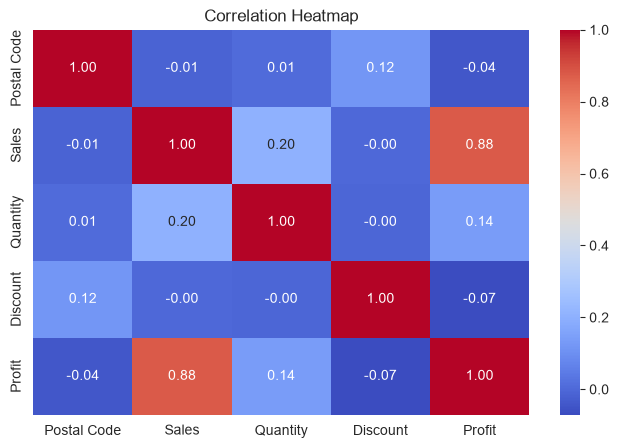

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
#The correlation heatmap shows the strength of relationships between numerical variables. Sales and Profit show a positive relationship, while Discount may have a weaker or negative relationship with Profit.

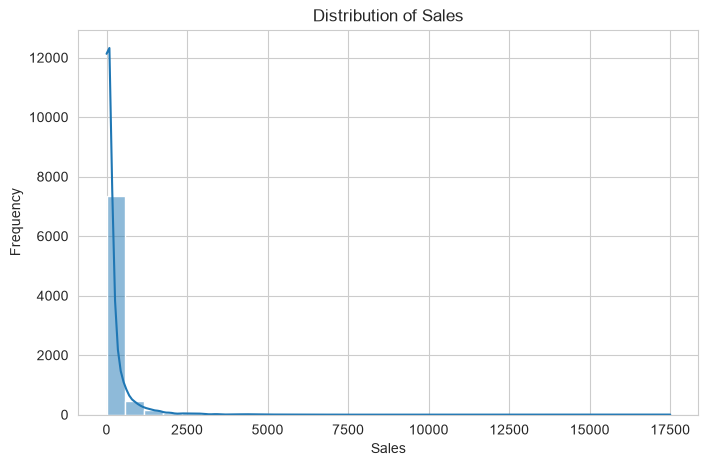

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


In [13]:
#The Sales distribution is right-skewed, indicating that most transactions have relatively low sales values while a smaller number of transactions have very high sales.

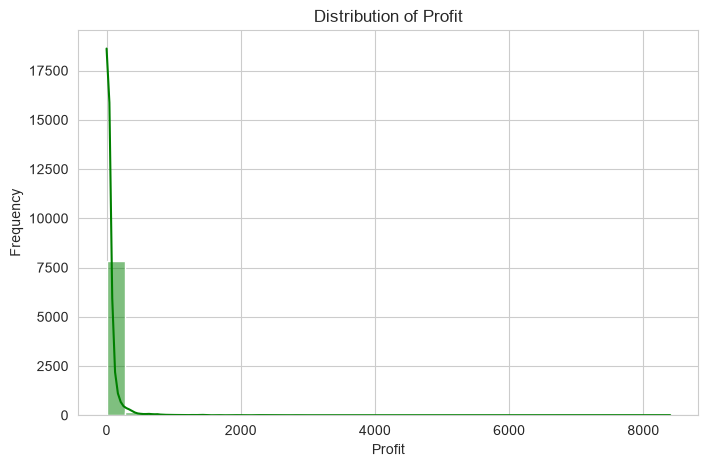

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Profit"], bins=30, kde=True, color="green")

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


In [17]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         716941.1400
Office Supplies    627130.1330
Furniture          483702.0985
Name: Sales, dtype: float64

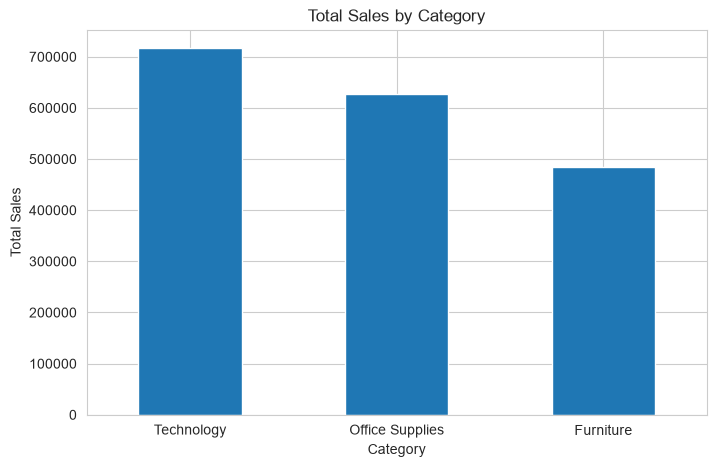

In [18]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Observation: Technology generates the highest total sales among the product categories, while the category with the lowest sales contributes comparatively less revenue.

In [19]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology         184034.8663
Office Supplies    178973.6823
Furniture           79345.8639
Name: Profit, dtype: float64

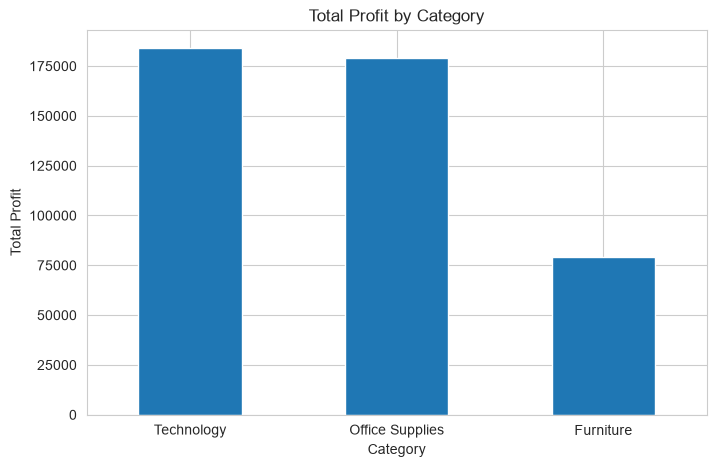

In [20]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

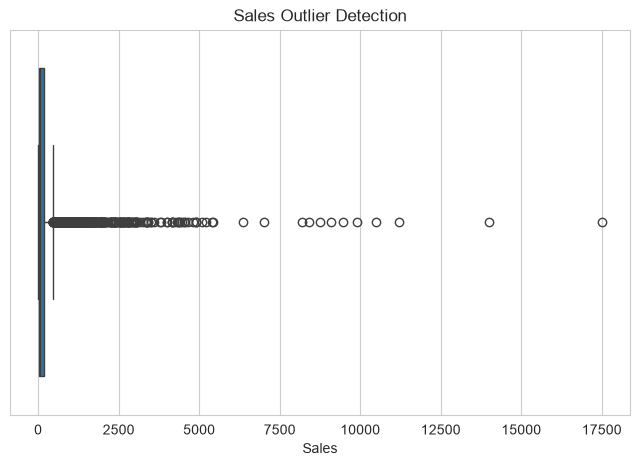

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outlier Detection")
plt.xlabel("Sales")
plt.show()

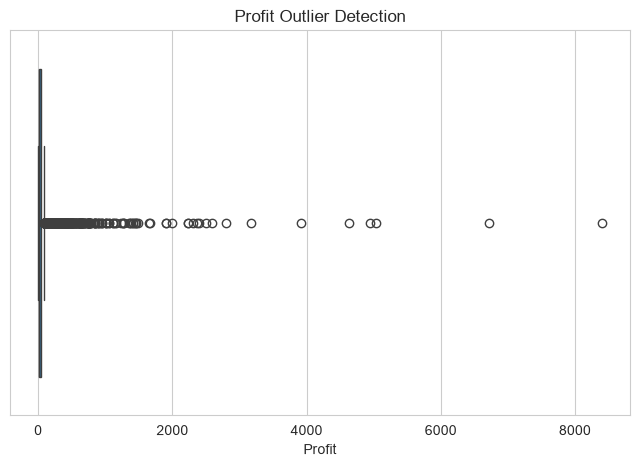

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outlier Detection")
plt.xlabel("Profit")
plt.show()

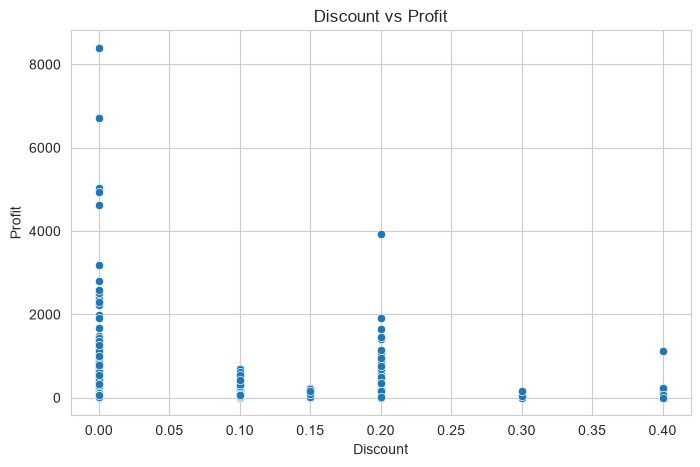

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [25]:
top_products = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Category
Technology         716941.1400
Office Supplies    627130.1330
Furniture          483702.0985
Name: Sales, dtype: float64

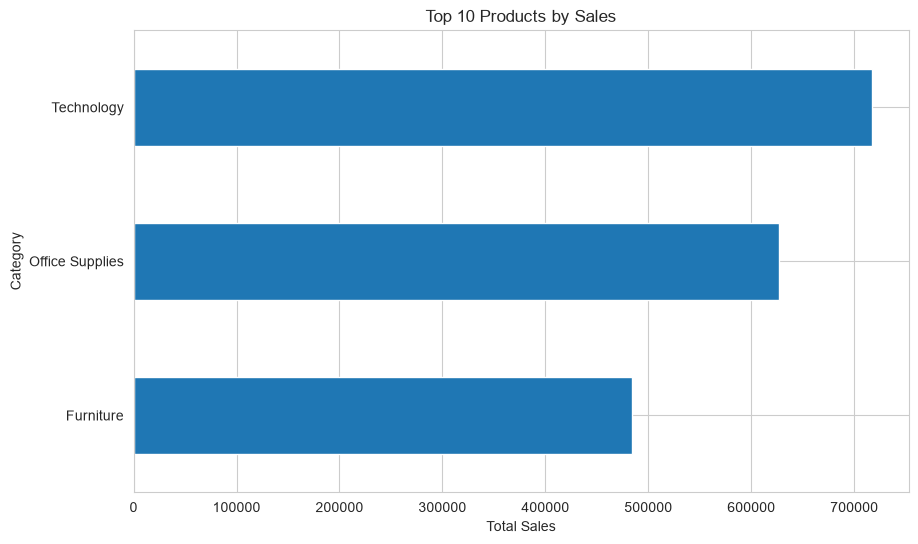

In [27]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.show()

# Top 3 Insights

### 1. Category Performance
Technology is one of the strongest-performing categories in terms of sales and contributes significantly to overall revenue.

### 2. Profitability and Discount
Higher discounts appear to negatively affect profit in several transactions, indicating that discount strategies should be monitored carefully.

### 3. Sales Trends
Monthly sales show fluctuations over time, indicating possible seasonal patterns and changes in customer demand.